In [1]:
from limited_data_experiment import (
    score_oracle,
    do_experiment,
    load_experiments_data_thm,
    make_pandas,
)
import numpy as np
from itertools import count
import multiprocessing as mp
from functools import partial
from matplotlib import pyplot as plt

import seaborn as sns

plt.rcdefaults()
font = 8
tex_fonts = {
    # "text.usetex": True,
    "font.family": "serif",
    "font.size": font,
    "axes.labelsize": font,
    "axes.titlesize": font,
    "xtick.labelsize": font,
    "ytick.labelsize": font,
    "legend.fontsize": font,
}


sns.set_theme(
    # context="talk",
    context="paper",
    # rc={"figure.figsize": (8, 6)},
    # palette="colorblind6",
    style="whitegrid",
    rc=tex_fonts,
)

ALL_RUNS = [100, 101, 102, 103, 104]

/home/porepy/porepy/src/porepy/numerics/nonlinear/nonlinear_solvers.py:14: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import trange  # type: ignore


# Random Experiment

In [2]:
sim_data_random, perf_data_random, solver_selector = load_experiments_data_thm(
    runs=ALL_RUNS, case='random'
)
solver_space = solver_selector.solver_space
num_solvers = solver_space.all_decisions_encoding.shape[0]
print(num_solvers)
solver_space.num_category_choices, solver_space.num_numerical_choices

32000


(21, 10)

In [3]:
df_sim_rand, df_perf_rand = make_pandas(
    sim_data=sim_data_random,
    perf_data=perf_data_random,
    seq_ids=ALL_RUNS,
)

df_perf_rand.tail()

,seq_id,sim_idx,reward,expectation,decision_idx,features
21844,104,24,-2.300950,100.0,25634,"[86400000.0, 312.99979567537406, 392.996669092..."
21845,104,24,-1.696662,100.0,9168,"[86400000.0, 312.9997956856579, 392.9966690912..."
21846,104,24,-1.701721,100.0,20961,"[48503837.43526125, 312.9997956856566, 392.996..."
21847,104,24,-1.948455,100.0,17111,"[48503837.43526125, 312.99982149659195, 392.99..."
21848,104,24,-2.036382,100.0,27103,"[48503837.43526125, 312.99982150196394, 392.99..."


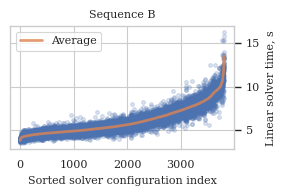

In [4]:
y_by_solver_id = [[] for _ in range(num_solvers)]
success_failure_by_solver_id = [[] for _ in range(num_solvers)]
for row in df_perf_rand.itertuples(index=False):
    if row.reward <= -200:
        success_failure_by_solver_id[row.decision_idx].append(False)
    else:
        success_failure_by_solver_id[row.decision_idx].append(True)
        y_by_solver_id[row.decision_idx].append(np.exp(-row.reward))

mean = []
std = []
for elem in y_by_solver_id:
    if len(elem) != 0:
        mean.append(np.mean(elem))
        std.append(np.std(elem))
    else:
        mean.append(np.nan)
        std.append(np.nan)

mean = np.array(mean)
std = np.array(std)

sorted_idx = np.argsort(mean)

idx = []
data = []
i = 0
for y in np.array(y_by_solver_id, dtype=object)[sorted_idx]:
    data.extend(y)
    idx.extend([i] * len(y))
    i += 1

plt.figure(figsize=(3,2))
plt.plot(mean[sorted_idx], color='C1', alpha=0.8, linewidth=2, label='Average')
plt.scatter(idx, data, marker='.', alpha=0.2, s=30)
# plt.ylim(1, 20)
# plt.yscale('log')
plt.grid(True)
plt.xlabel('Sorted solver configuration index')
plt.ylabel('Linear solver time, s')
ax = plt.gca()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
plt.legend()
plt.title('Sequence B')
plt.tight_layout()

plt.savefig('figures/thm_sorted_run_times.png', dpi=600)

In [5]:
num_always_success = 0
num_always_failure = 0
num_swinging = 0

for x in success_failure_by_solver_id:
    if len(x) == 0:
        continue
    elif np.all(x):
        num_always_success += 1
    elif not np.any(x):
        num_always_failure += 1
    else:
        num_swinging += 1

print(num_always_success, num_always_failure, num_swinging)

3491 255 319


In [6]:
import pandas as pd

success = df_perf_rand.reward > -200
ysuccess = np.exp(-df_perf_rand[success].reward)
num_solvers_tried = sum(len(x) != 0 for x in success_failure_by_solver_id)

stats = {
    'num_solvers': [num_solvers],
    'num_points': df_perf_rand.shape[0],
    '% solvers_tried': num_solvers_tried / num_solvers * 100,
    'Success %': np.sum(success) / success.size * 100,
    '% num_always_success': num_always_success / num_solvers_tried * 100,
    '% num_always_failure': num_always_failure / num_solvers_tried * 100,
    '% num_swinging_success_failure': num_swinging / num_solvers_tried * 100,
    'Run time avg': ysuccess.mean(),
    'Run time median': ysuccess.median(),
    'Run time min': ysuccess.min(),
    'Run time max': ysuccess.max(),
}
pd.DataFrame(stats).T

,0
num_solvers,32000.000000
num_points,21849.000000
% solvers_tried,12.703125
Success %,90.722688
% num_always_success,85.879459
% num_always_failure,6.273063
% num_swinging_success_failure,7.847478
Run time avg,5.994399
Run time median,5.509107
Run time min,3.494974


# Solver Selection Experiment

In [7]:
sim_data, perf_data, solver_selector = load_experiments_data_thm(
    runs=ALL_RUNS, case='solver_selection'
)

num_solvers = solver_selector.solver_space.all_decisions_encoding.shape[0]

df_sim, df_perf = make_pandas(
    sim_data=sim_data,
    perf_data=perf_data,
    seq_ids=ALL_RUNS,
)
df_perf.head()

,seq_id,sim_idx,reward,expectation,decision_idx,features
0,100,0,-2.485214,100.0,23654,"[86400.0, 393.0, 393.0, 2.759353900791754e-16,..."
1,100,0,-1.833377,100.0,15795,"[86400.0, 392.95448828704053, 393.634334876044..."
2,100,0,-1.418059,100.0,860,"[86400.0, 392.95444601969496, 393.104258092052..."
3,100,0,-1.504890,100.0,5390,"[86400.0, 392.95444601969155, 393.104206878979..."
4,100,0,-200.000000,100.0,29802,"[86400.0, 392.95444601969155, 393.104206878980..."


In [8]:
y_by_solver_id = [[] for _ in range(num_solvers)]
success_failure_by_solver_id = [[] for _ in range(num_solvers)]
for row in df_perf.itertuples(index=False):
    if row.reward <= -200:
        success_failure_by_solver_id[row.decision_idx].append(False)
    else:
        success_failure_by_solver_id[row.decision_idx].append(True)
        y_by_solver_id[row.decision_idx].append(np.exp(-row.reward))

num_always_success = 0
num_always_failure = 0
num_swinging = 0

for x in success_failure_by_solver_id:
    if len(x) == 0:
        continue
    elif np.all(x):
        num_always_success += 1
    elif not np.any(x):
        num_always_failure += 1
    else:
        num_swinging += 1

print(num_always_success, num_always_failure, num_swinging)

482 9 6


In [9]:
success[64:].sum()

19761

In [10]:
import pandas as pd

batch_size = 64
success = df_perf.reward > -200
ysuccess = np.exp(-df_perf[success].reward)
num_solvers_tried = sum(len(x) != 0 for x in success_failure_by_solver_id)

stats = {
    'num_solvers': [num_solvers],
    'num_points': df_perf.shape[0],
    '% solvers_tried': num_solvers_tried / num_solvers * 100,
    'Success %': np.sum(success[batch_size:]) / (success[batch_size:].size) * 100,
    '% num_always_success': num_always_success / num_solvers_tried * 100,
    '% num_always_failure': num_always_failure / num_solvers_tried * 100,
    '% num_swinging_success_failure': num_swinging / num_solvers_tried * 100,
    'Run time avg': ysuccess.mean(),
    'Run time median': ysuccess.median(),
    'Run time min': ysuccess.min(),
    'Run time max': ysuccess.max(),
}
pd.DataFrame(stats).T

,0
num_solvers,32000.000000
num_points,20085.000000
% solvers_tried,1.553125
Success %,98.676390
% num_always_success,96.981891
% num_always_failure,1.810865
% num_swinging_success_failure,1.207243
Run time avg,4.406397
Run time median,4.316235
Run time min,3.327878


In [11]:
# data = df_perf.time[df_perf.reward > -200]
# data_rand = df_perf.time[df_perf.reward > -200]

# bins = 200
# bins = np.linspace(min(data_rand), max(data_rand), bins)
# plt.hist(data_rand, bins=bins, density=False, alpha=0.6, edgecolor="black", label='Random Selection', histtype='stepfilled')
# plt.hist(data, bins=bins, density=False, alpha=0.6, edgecolor="black", label='Solver Selection Algorithm', histtype='stepfilled')

# plt.xlabel("Time, s")
# plt.ylabel("Probability Density")
# # plt.yscale('log')
# # plt.grid()
# plt.legend()

In [12]:
# data = df_perf_new_rand.time[df_perf_new_rand.reward > -200]
# # bins = np.logspace(np.log10(min(data)), np.log10(max(data)), 30)
# bins = 100
# plt.hist(data, bins=bins, density=True, alpha=0.7, edgecolor="black")
# plt.xlabel("Time, s")
# plt.ylabel("Probability Density")
# # plt.xscale('log')

In [13]:
# sim_data, perf_data, solver_selector = load_experiments_data_thm(
#     runs=ALL_RUNS, random_selection=False
# )

# num_solvers = solver_selector.solver_space.all_decisions_encoding.shape[0]

# df_sim, df_perf = make_pandas(
#     sim_data=sim_data,
#     perf_data=perf_data,
#     seq_ids=ALL_RUNS,
# )
# X = np.stack(df_perf.features)
# X = np.clip(X, -1e10, 1e10)
# y = np.array(df_perf.reward)



# for seq_id in ALL_RUNS:
#     x = df_sim[df_sim.seq_id == seq_id]
#     time = np.array(x.real_solve_time)
#     plt.plot(np.array(time), label=seq_id)
# plt.legend()
# # plt.yscale('log')
# # plt.ylim(top=20, bottom=-1)

# plt.show()

# # df_perf = df_perf[df_perf.seq_id == 104]

# y_by_solver_id = np.zeros(num_solvers)
# count_solver_id = np.bincount(np.array(df_perf.decision_idx), minlength=num_solvers)
# np.add.at(y_by_solver_id, np.array(df_perf.decision_idx), np.array(df_perf.reward))
# tried = (count_solver_id > 0)# & (y_by_solver_id > -1000)
# y_by_solver_id[tried] /= count_solver_id[tried]

# sorted_idx = np.argsort(y_by_solver_id[tried])[::-1]

# plt.plot(np.exp(-y_by_solver_id[tried][sorted_idx][:450]))
# plt.yscale('log')

In [14]:
# sim_data, perf_data, solver_selector = load_experiments_data_thm(
#     runs=ALL_RUNS, random_selection=False
# )

# num_solvers = solver_selector.solver_space.all_decisions_encoding.shape[0]

# df_sim, df_perf = make_pandas(
#     sim_data=sim_data,
#     perf_data=perf_data,
#     seq_ids=ALL_RUNS,
# )

In [15]:
# y_by_solver_id = [[] for _ in range(num_solvers)]
# success_failure_by_solver_id = [[] for _ in range(num_solvers)]
# for row in df_perf.itertuples(index=False):
#     if row.reward <= -200:
#         success_failure_by_solver_id[row.decision_idx].append(False)
#     else:
#         success_failure_by_solver_id[row.decision_idx].append(True)
#         y_by_solver_id[row.decision_idx].append(np.exp(-row.reward))

# mean = []
# std = []
# for elem in y_by_solver_id:
#     if len(elem) != 0:
#         mean.append(np.mean(elem))
#         std.append(np.std(elem))
#     else:
#         mean.append(np.nan)
#         std.append(np.nan)

# mean = np.array(mean)
# std = np.array(std)

# sorted_idx = np.argsort(mean)

In [16]:
# num_always_success = 0
# num_always_failure = 0
# num_swinging = 0

# for x in success_failure_by_solver_id:
#     if len(x) == 0:
#         continue
#     elif np.all(x):
#         num_always_success += 1
#     elif not np.any(x):
#         num_always_failure += 1
#     else:
#         num_swinging += 1

# print(num_always_success, num_always_failure, num_swinging)

In [17]:
# import pandas as pd

# success = df_perf.reward > -200
# ysuccess = np.exp(-df_perf[success].reward)

# stats = {
#     'num_solvers': [num_solvers],
#     'num_points': df_perf.shape[0],
#     '% solvers_tried': sum(len(x) != 0 for x in y_by_solver_id) / num_solvers * 100,
#     '% num_solvers_not_tried': sum(len(x) == 0 for x in y_by_solver_id) / num_solvers * 100,
#     '% num_always_success': num_always_success / num_solvers * 100,
#     '% num_always_failure': num_always_failure / num_solvers * 100,
#     '% num_swinging_success_failure': num_swinging / num_solvers * 100,
#     'Run time avg': ysuccess.mean(),
#     'Run time median': ysuccess.median(),
#     'Run time min': ysuccess.min(),
#     'Run time max': ysuccess.max(),
# }
# pd.DataFrame(stats).T

In [18]:
# import pandas as pd
# from solver_selection_thm.solver_space import explain_decisions

# solver_space = solver_selector.solver_space
# decision_names, decision_ranges = explain_decisions(solver_space)


# perf_dict_for_pandas = []
# for row in df_perf.itertuples(index=False):
#     decision_vec = solver_space.all_decisions_encoding[row.decision_idx]
#     perf_dict_for_pandas.append(
#         {name: val for name, val in zip(decision_names, decision_vec)}
#     )

# column_dtypes = {x: bool for x in decision_names[:solver_space.num_category_choices]} 
# column_dtypes |= {x: float for x in decision_names[solver_space.num_category_choices:]} 
# tmp = pd.DataFrame(perf_dict_for_pandas).astype(column_dtypes)

# df_perf_new = pd.concat([df_perf, tmp], axis=1)
# df_perf_new['time'] = np.exp(-df_perf_new.reward)
# df_perf_new = df_perf_new.drop('features', axis=1)
# df_perf_new

/tmp/ipykernel_2167407/2006295098.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="upper left", bbox_to_anchor=(1, 1))


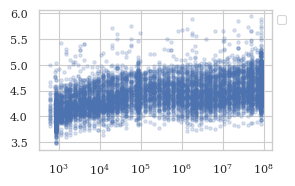

In [19]:
plt.figure(figsize=(3,2))

tmp = df_sim[df_sim.sim_idx.isin(range(15, 25))]
x = np.array(tmp.simulation_dt)
y = np.array(tmp.real_solve_time)

plt.scatter(x, y, alpha=0.2, marker='.')
# plt.ylim(3.5, 9.5)
plt.legend(loc="upper left", bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.xscale('log')

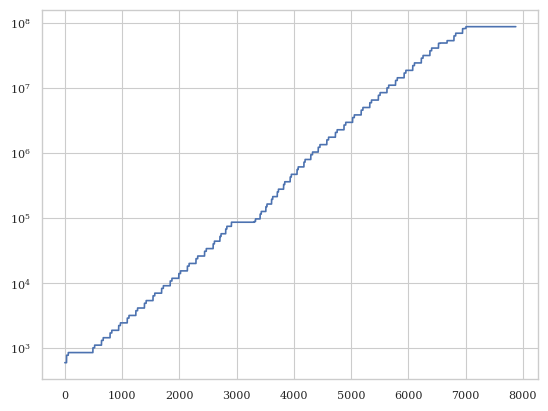

In [20]:
plt.plot(np.sort(x))
plt.yscale('log')

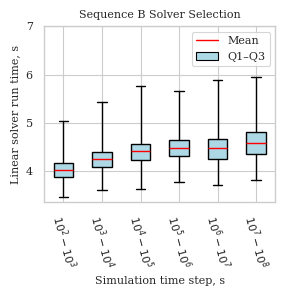

In [21]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

bins = 10.0 ** np.arange(2, 9)
perf_data_per_dt = []
xticklabels = []
for bin_start, bin_end in zip(bins[:-1], bins[1:]):
    perf_data_per_dt.append(y[(x >= bin_start) & (x < bin_end)])
    pow = int(np.log10(bin_start))
    xticklabels.append("$10^{" + str(pow) + "} - 10^{" + str(pow + 1) + "}$")


plt.figure(figsize=(3, 3))
plt.boxplot(
    perf_data_per_dt,
    patch_artist=True,
    meanline=True,
    boxprops=dict(linewidth=1, facecolor="lightblue"),
    whiskerprops=dict(color="black", linewidth=1),
    medianprops=dict(visible=False),
    showmeans=True,
    meanprops=dict(linestyle="-", linewidth=1, color="red"),  # mean as red line
    flierprops=dict(marker="", linestyle="none"),  # disables outliers
    whis=[0, 100],  # whiskers go to min and max
)
plt.xticks(np.arange(1, len(bins)), xticklabels, rotation=-75)
plt.title("Sequence B Solver Selection")

plt.xlabel('Simulation time step, s')
plt.ylabel(r"Linear solver run time, s")

mean_line = mlines.Line2D([], [], color='red', linestyle='-', linewidth=1, label='Mean')
iqr_box = mpatches.Patch(facecolor='lightblue', edgecolor='black', label='Q1–Q3')
plt.legend(handles=[mean_line, iqr_box], loc='upper right')
plt.ylim(top=7)

plt.tight_layout()
plt.savefig("figures/thm_boxplot_sim_dt.png", dpi=600)

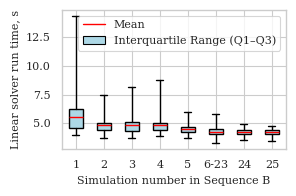

In [22]:
import matplotlib.lines as mlines
import matplotlib.patches as mpatches

num_sims = 25
num_left = 5
num_right = 2
assert num_sims >= (num_left + num_right)
sims = [[x] for x in range(num_left)] + [range(num_left, num_sims - num_right)] + [[x] for x in range(num_sims - num_right, num_sims)]
perf_data_per_sim = []

for sim_id in sims:
    tmp = df_perf[df_perf.sim_idx.isin(sim_id)]
    y = np.exp(-tmp.reward[tmp.reward > -200])
    perf_data_per_sim.append(np.array(y))

plt.figure(figsize=(3, 2))
plt.boxplot(
    perf_data_per_sim,
    patch_artist=True,
    meanline=True,
    boxprops=dict(linewidth=1, facecolor="lightblue"),
    whiskerprops=dict(color='black', linewidth=1),
    medianprops=dict(visible=False),
    showmeans=True,
    meanprops=dict(linestyle='-', linewidth=1, color='red'),  # mean as red line
    flierprops=dict(marker='', linestyle='none'),  # disables outliers
    whis=[0, 100],  # whiskers go to min and max
)
plt.xticks(range(1, num_left + 1 + num_right + 1), labels=[str(x+1) for x in range(num_left)] + [f'{num_left+1}-{num_sims-num_right}'] + [str(x+1) for x in range(num_sims - num_right, num_sims)])

mean_line = mlines.Line2D([], [], color='red', linestyle='-', linewidth=1, label='Mean')
iqr_box = mpatches.Patch(facecolor='lightblue', edgecolor='black', label='Interquartile Range (Q1–Q3)')

plt.legend(handles=[mean_line, iqr_box], loc='upper right')
plt.xlabel("Simulation number in Sequence B")
plt.ylabel("Linear solver run time, s")
# plt.ylim(0, 7)
plt.tight_layout()
plt.savefig('figures/thm_boxplot_sim_number.png', dpi=600)

Text(0.5, 0, 'Linear solve attempt')

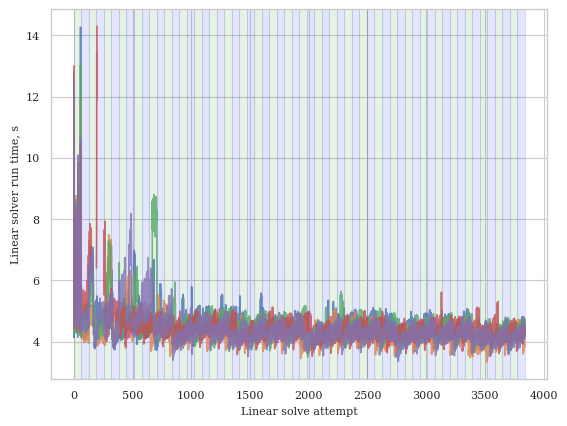

In [23]:
batch_size = 64
max_points = batch_size * 60
num_batches = max_points // batch_size

data_len = 0
for seq_id in ALL_RUNS:
    tmp = df_perf[df_perf.seq_id == seq_id]
    failure = np.array(tmp.reward <= -200)
    y = np.exp(-np.array(tmp.reward))
    y[failure] = np.nan
    y = y[:max_points]
    plt.plot(y, alpha=0.8)
    data_len = max(data_len, y.size)


colors = ["green", "blue"]

for b in range(num_batches):
    if (batch_size * (b + 1)) > data_len:
        break 
    plt.axvspan(batch_size * b, batch_size * (b + 1), alpha=0.1, color=colors[b % 2])

plt.ylabel("Linear solver run time, s")
plt.xlabel("Linear solve attempt")

In [24]:
num_data_points_in_sim = []
for sim_id in range(25):
    tmp = df_perf[(df_perf.seq_id == ALL_RUNS[0]) & (df_perf.sim_idx == sim_id)]
    num_data_points_in_sim.append(tmp.shape[0])
num_data_points_in_sim

[166,
 159,
 201,
 159,
 159,
 155,
 154,
 154,
 155,
 154,
 160,
 159,
 160,
 160,
 159,
 159,
 159,
 159,
 160,
 159,
 161,
 160,
 160,
 160,
 160]

In [25]:
(166+159) / 64

5.078125

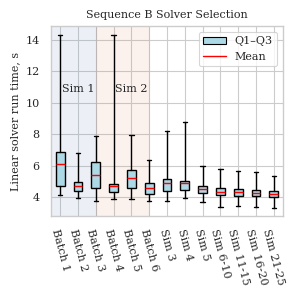

In [26]:
batches = range(6)
perf_data_per_batch = []

for bstart in batches:
    bend = bstart + 1
    tmp_list = []
    perf_data_per_batch.append(tmp_list)
    for seq_id in ALL_RUNS:
        tmp = df_perf[df_perf.seq_id == seq_id][bstart * batch_size : bend * batch_size]
        y = np.exp(-tmp.reward[tmp.reward > -200])
        tmp_list.extend(y.tolist())

sims = [[2], [3], [4], list(range(5,10)), list(range(10,15)), list(range(15,20)), list(range(20,25))]

for sim_id in sims:
    tmp = df_perf[df_perf.sim_idx.isin(sim_id)]
    y = np.exp(-tmp.reward[tmp.reward > -200])
    perf_data_per_batch.append(np.array(y))


plt.figure(figsize=(3, 3))
_ = plt.boxplot(
    perf_data_per_batch,
    patch_artist=True,
    meanline=True,
    boxprops=dict(linewidth=1, facecolor="lightblue"),
    whiskerprops=dict(color="black", linewidth=1),
    medianprops=dict(visible=False),
    showmeans=True,
    meanprops=dict(linestyle="-", linewidth=1, color="red"),  # mean as red line
    flierprops=dict(marker="", linestyle="none"),  # disables outliers
    whis=[0, 100],  # whiskers go to min and max
)

# plt.xticks(
#     range(1, len(batches) + 1),
#     labels=[
#         start + 1 if (end - start) == 1 else f"{start + 1}-{end + 1}"
#         for start, end in batches
#     ],
# )
# for i, tick in enumerate(plt.gca().get_xticklabels()):
#     if i >= 4:  # rotate ticks 4-8
#         tick.set_rotation(-45)
#     else:  # leave 0-3 unrotated
#         tick.set_rotation(0)

plt.axvspan(0, 3, alpha=0.1, color='C0')
plt.axvspan(3, 6, alpha=0.1, color='C1')
plt.xticks(
    range(1, len(perf_data_per_batch) + 1),
    [f'Batch {i+1}' for i in batches] + [f'Sim {x[0]+1}' if len(x)==1 else f'Sim {min(x)+1}-{max(x)+1}' for x in sims],
    rotation=-75
)
plt.text(2, 10.7, 'Sim 1', ha='center')
plt.text(5, 10.7, 'Sim 2', ha='center')

plt.xlim(left=0.5)
plt.title('Sequence B Solver Selection')

mean_line = mlines.Line2D([], [], color='red', linestyle='-', linewidth=1, label='Mean')
iqr_box = mpatches.Patch(facecolor='lightblue', edgecolor='black', label='Q1–Q3')
plt.legend(handles=[iqr_box, mean_line], loc='upper right')

# plt.xlabel("Batch number Sequence B")
plt.ylabel(r"Linear solver run time, s")
plt.tight_layout()
plt.savefig("figures/thm_boxplot_batches_and_simulations.png", dpi=600)

In [27]:
160 * 2

320

0-64
64-128
128-192 - end of 1st
192-256
256-320
320-384 - end of 3rd

In [28]:
64*6

384

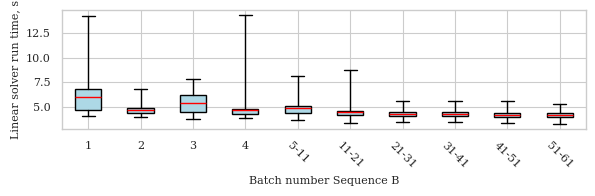

In [29]:
batches = [
    [0, 1],
    [1, 2],
    [2, 3],
    [3, 4],
    [4, 10],
    [10, 20],
    [20, 30],
    [30, 40],
    [40, 50],
    [50, 60],
]
perf_data_per_batch = []

for bstart, bend in batches:
    tmp_list = []
    perf_data_per_batch.append(tmp_list)
    for seq_id in ALL_RUNS:
        tmp = df_perf[df_perf.seq_id == seq_id][bstart * batch_size : bend * batch_size]
        y = np.exp(-tmp.reward[tmp.reward > -200])
        tmp_list.extend(y.tolist())


plt.figure(figsize=(6, 2))
_ = plt.boxplot(
    perf_data_per_batch,
    patch_artist=True,
    meanline=True,
    boxprops=dict(linewidth=1, facecolor="lightblue"),
    whiskerprops=dict(color="black", linewidth=1),
    medianprops=dict(visible=False),
    showmeans=True,
    meanprops=dict(linestyle="-", linewidth=1, color="red"),  # mean as red line
    flierprops=dict(marker="", linestyle="none"),  # disables outliers
    whis=[0, 100],  # whiskers go to min and max
)

plt.xticks(
    range(1, len(batches) + 1),
    labels=[
        start + 1 if (end - start) == 1 else f"{start + 1}-{end + 1}"
        for start, end in batches
    ],
)
for i, tick in enumerate(plt.gca().get_xticklabels()):
    if i >= 4:  # rotate ticks 4-8
        tick.set_rotation(-45)
    else:  # leave 0-3 unrotated
        tick.set_rotation(0)

# mean_line = mlines.Line2D([], [], color='red', linestyle='-', linewidth=1, label='Mean')
# iqr_box = mpatches.Patch(facecolor='lightblue', edgecolor='black', label='Interquartile Range (Q1–Q3)')

# plt.legend(handles=[iqr_box, mean_line], loc='upper center', bbox_to_anchor=(1, 1))

plt.xlabel("Batch number Sequence B")
plt.ylabel("Linear solver run time, s")
plt.tight_layout()
plt.savefig("figures/thm_boxplot_batches.png", dpi=600)

In [30]:
len(perf_data_per_batch)

10

* batch size running window
* batch size one simulation
* hist - individual sims
* hist - batch updates
* vertical bars of 25 simulations - one sim is 1 data point

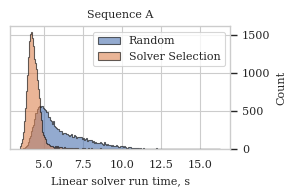

In [31]:
data = np.exp(-df_perf.reward[df_perf.reward > -200])
data_rand = np.exp(-df_perf_rand.reward[df_perf_rand.reward > -200])

bins = 200
bins = np.linspace(min(data_rand), max(data_rand), bins)
plt.figure(figsize=(3,2))
plt.hist(data_rand, bins=bins, density=False, alpha=0.6, edgecolor="black", label='Random', histtype='stepfilled')
plt.hist(data, bins=bins, density=False, alpha=0.6, edgecolor="black", label='Solver Selection', histtype='stepfilled')

plt.xlabel("Linear solver run time, s")
plt.ylabel("Count")
# plt.yscale('log')
ax = plt.gca()
ax.yaxis.tick_right()
ax.yaxis.set_label_position("right")
plt.legend()
plt.title('Sequence A')
plt.tight_layout()
plt.savefig('figures/thm_runtime_histogram.png', dpi=600)

In [32]:
# from limited_data_experiment import (
#     EpsGreedyExplorationModel,
#     GradientBoostingRegressor,
#     IncrementalRefitModel,
#     RidgeClassifier,
#     StandardScaler,
#     TwoEstimators,
#     make_pipeline,
#     stack_features_solvers,
# )
# from time import time
# from tqdm import tqdm
# from solver_selection_thm.performance_predictor import InitialExplorationEstimator


# def ml_overhead(df_perf: pd.DataFrame):
#     df_perf = df_perf[df_perf.seq_id == ALL_RUNS[0]]
#     X = np.stack(df_perf.features)
#     X = np.clip(X, -1e10, 1e10)

#     online_model = InitialExplorationEstimator(
#         num_initial_exploration=64,
#         batch_size=64,
#         model=EpsGreedyExplorationModel(
#             eps=0,
#             eps1=0.9,
#             model=TwoEstimators(
#                 classifier=IncrementalRefitModel(
#                     model=make_pipeline(StandardScaler(), RidgeClassifier())
#                 ),
#                 regressor=IncrementalRefitModel(
#                     model=GradientBoostingRegressor(random_state=42)
#                 ),
#             ),
#         ),
#     )
#     tpred = []
#     tfit = []

#     all_solvers = solver_selector.solver_space.all_decisions_encoding
#     # only solution context (no solvers encoding)
#     X_context = X[:, : -all_solvers.shape[1]]

#     for Xfeature in tqdm(X_context):
#         t0 = time()
#         x_to_predict = stack_features_solvers(Xfeature, all_solvers)
#         online_model.select_solver(x_to_predict)
#         tpred.append(time() - t0)
#         t0 = time()
#         online_model.partial_fit(
#             features=x_to_predict[np.random.randint(all_solvers.shape[0])],
#             solve_time=np.random.rand(),
#             construct_time=np.random.rand(),
#             success=True,
#         )
#         tfit.append(time() - t0)
#     return np.array(tpred), np.array(tfit)


# tpred, tfit = ml_overhead(df_perf)

In [33]:
# plt.figure(figsize=(3,2))
# plt.plot(np.cumsum(tpred), label='Selection')
# plt.plot(np.cumsum(tfit), label='Feedback')
# plt.legend()
# plt.ylabel('Cumulative\noverhead, s')
# plt.xlabel('Num. linear systems seen')
# plt.title('Sequence B')
# plt.tight_layout()
# plt.savefig('figures/thm_ml_overhead.png', dpi=600)

In [34]:
# np.mean(tpred[64:]), np.std(tpred[64:])

In [35]:
# plt.plot(tfit)

# Expert Experiment

In [36]:
sim_data_expert, perf_data_expert, solver_selector = load_experiments_data_thm(
    runs=ALL_RUNS, case='expert'
)

num_solvers = solver_selector.solver_space.all_decisions_encoding.shape[0]

df_sim_expert, df_perf_expert = make_pandas(
    sim_data=sim_data_expert,
    perf_data=perf_data_expert,
    seq_ids=ALL_RUNS,
)
df_sim_expert.tail()

failed to load EXPERT_run_102_fthm_xinj=0.3_yinj=0.0_zinj=0.5_xprod=0.7_yprod=1.0_zprod=0.5


,seq_id,sim_idx,ts_idx,ls_idx,real_solve_time,krylov_iters,petsc_converged_reason,cfl,simulation_dt,enthalpy_max,enthalpy_mean,fourier_max,fourier_mean
19651,104,24,52,1,4.988554,39,2,10.227221,8.640000e+07,0.002055,0.000010,1.503100e-07,6.310546e-09
19652,104,24,52,2,5.047638,34,2,10.227221,8.640000e+07,0.002055,0.000010,1.503084e-07,6.310227e-09
19653,104,24,53,0,5.240297,45,2,5.741429,4.850384e+07,0.002055,0.000010,1.503084e-07,6.310227e-09
19654,104,24,53,1,5.179163,39,2,5.741439,4.850384e+07,0.002053,0.000009,1.517193e-07,6.336285e-09
19655,104,24,53,2,4.752254,34,2,5.741439,4.850384e+07,0.002053,0.000009,1.517173e-07,6.336107e-09


In [37]:
import pandas as pd

success = df_perf_expert.reward > -200
ysuccess = np.exp(-df_perf_expert[success].reward)
num_solvers_tried = sum(len(x) != 0 for x in success_failure_by_solver_id)

stats = {
    'num_solvers': [num_solvers],
    'num_points': df_perf_expert.shape[0],
    '% solvers_tried': num_solvers_tried / num_solvers * 100,
    'Success %': np.sum(success[batch_size:]) / (success[batch_size:].size) * 100,
    'Run time avg': ysuccess.mean(),
    'Run time median': ysuccess.median(),
    'Run time min': ysuccess.min(),
    'Run time max': ysuccess.max(),
}
pd.DataFrame(stats).T

,0
num_solvers,32000.000000
num_points,19650.000000
% solvers_tried,1.553125
Success %,100.000000
Run time avg,4.232068
Run time median,4.209049
Run time min,3.235992
Run time max,10.299226


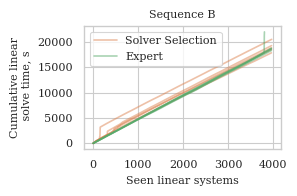

In [38]:
plt.figure(figsize=(3,2))

first_time = True
for seq_id in ALL_RUNS:
    # y = np.array(df_perf.reward[(df_perf.reward > -200) & (df_perf.seq_id == seq_id)])
    # y = np.exp(-y)
    y = np.array(df_sim.real_solve_time[df_sim.seq_id == seq_id])
    y = np.cumsum(y)
    kwargs = {}
    if first_time:
        first_time = False
        kwargs = dict(label='Solver Selection')
    plt.plot(y, color="C1", **kwargs, alpha=0.5)

first_time = True
for seq_id in ALL_RUNS:
    # y = np.array(df_perf_expert.reward[(df_perf_expert.reward > -200) & (df_perf_expert.seq_id == seq_id)])
    # y = np.exp(-y)
    y = np.array(df_sim_expert.real_solve_time[df_sim_expert.seq_id == seq_id])
    y = np.cumsum(y)
    kwargs = {}
    if first_time:
        first_time = False
        kwargs = dict(label='Expert')
    plt.plot(y, color="C2", **kwargs, alpha=0.5)


plt.ylabel('Cumulative linear\n solve time, s')
plt.xlabel('Seen linear systems')
plt.legend()
plt.title('Sequence B')
plt.tight_layout()
plt.savefig('figures/thm_runtime_expert.png', dpi=600)

# Analyzing Individual Decisions

In [39]:
import pandas as pd
from solver_selection_thm.solver_space import explain_decisions

solver_space = solver_selector.solver_space
decision_names, decision_ranges = explain_decisions(solver_space)


perf_dict_for_pandas = []
for row in df_perf.itertuples(index=False):
    decision_vec = solver_space.all_decisions_encoding[row.decision_idx]
    perf_dict_for_pandas.append(
        {name: val for name, val in zip(decision_names, decision_vec)}
    )

column_dtypes = {x: bool for x in decision_names[:solver_space.num_category_choices]} 
column_dtypes |= {x: float for x in decision_names[solver_space.num_category_choices:]} 
tmp = pd.DataFrame(perf_dict_for_pandas).astype(column_dtypes)

df_perf_detailed = pd.concat([df_perf, tmp], axis=1)
df_perf_detailed['time'] = np.exp(-df_perf_detailed.reward)
df_perf_detailed = df_perf_detailed.drop('features', axis=1)
df_perf_detailed

,seq_id,sim_idx,reward,expectation,decision_idx,hypre - SOR/Jacobi,hypre - V,hypre,PetscFieldSplitScheme - hypre - SOR/Jacobi,PetscFieldSplitScheme - hypre - V,...,LinearTransformedScheme - hypre - pc_hypre_boomeramg_agg_nl,LinearTransformedScheme - hypre - pc_hypre_boomeramg_grid_sweeps_all,LinearTransformedScheme - PetscFieldSplitScheme - hypre - python_pc_hypre_boomeramg_strong_threshold,LinearTransformedScheme - PetscFieldSplitScheme - hypre - python_pc_hypre_boomeramg_agg_nl,LinearTransformedScheme - PetscFieldSplitScheme - hypre - python_pc_hypre_boomeramg_grid_sweeps_all,LinearTransformedScheme - ksp_gmres_restart,LinearTransformedScheme - PetscCompositeScheme - hypre - pc_hypre_boomeramg_strong_threshold,LinearTransformedScheme - PetscCompositeScheme - hypre - pc_hypre_boomeramg_agg_nl,LinearTransformedScheme - PetscCompositeScheme - hypre - pc_hypre_boomeramg_grid_sweeps_all,time
0,100,0,-2.485214,100.000000,23654,False,True,True,False,False,...,1.0,1.0,0.0,0.0,0.0,100.0,0.8,1.0,1.0,1.200369e+01
1,100,0,-1.833377,100.000000,15795,True,False,True,False,False,...,0.0,2.0,0.0,0.0,0.0,100.0,0.8,1.0,2.0,6.254972e+00
2,100,0,-1.418059,100.000000,860,True,True,True,False,True,...,1.0,2.0,0.5,0.0,1.0,100.0,0.0,0.0,0.0,4.129098e+00
3,100,0,-1.504890,100.000000,5390,True,True,True,False,False,...,0.0,2.0,0.0,0.0,0.0,100.0,0.7,1.0,1.0,4.503659e+00
4,100,0,-200.000000,100.000000,29802,False,False,True,False,False,...,1.0,1.0,0.0,0.0,0.0,100.0,0.5,1.0,1.0,7.225974e+86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20080,104,24,-1.477380,-1.450702,2134,True,True,True,False,False,...,1.0,1.0,0.0,0.0,0.0,100.0,0.8,1.0,1.0,4.381451e+00
20081,104,24,-1.420327,-1.450702,2134,True,True,True,False,False,...,1.0,1.0,0.0,0.0,0.0,100.0,0.8,1.0,1.0,4.138473e+00
20082,104,24,-1.533895,-1.448660,2134,True,True,True,False,False,...,1.0,1.0,0.0,0.0,0.0,100.0,0.8,1.0,1.0,4.636199e+00
20083,104,24,-1.476125,-1.448660,2134,True,True,True,False,False,...,1.0,1.0,0.0,0.0,0.0,100.0,0.8,1.0,1.0,4.375956e+00


In [40]:
def make_hist(df: pd.DataFrame, label: str):
    bins = 30
    bins = np.linspace(3, 13, bins, endpoint=True)
    y = df.reward[df.reward > -200]
    y = np.exp(-y)
    plt.hist(y, label=f'{label}, {y.size} points', alpha=0.6, bins=bins, density=True, edgecolor="black", histtype='stepfilled')

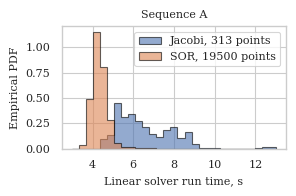

In [41]:
plt.figure(figsize=(3,2))
make_hist(df_perf_detailed[df_perf_detailed['hypre - Jacobi'] == True], label='Jacobi')
make_hist(df_perf_detailed[df_perf_detailed['hypre - SOR/Jacobi'] == True], label='SOR')
plt.ylabel('Empirical PDF')
plt.xlabel('Linear solver run time, s')
plt.title('Sequence A')
plt.legend(loc='upper right')
plt.tight_layout()
# plt.savefig('figures/thm_jacobi_vs_sor.png', dpi=600)

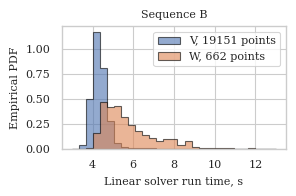

In [42]:
plt.figure(figsize=(3,2))
make_hist(df_perf_detailed[df_perf_detailed['hypre - V'] == True], label='V')
make_hist(df_perf_detailed[df_perf_detailed['hypre - W'] == True], label='W')
plt.ylabel('Empirical PDF')
plt.xlabel('Linear solver run time, s')
plt.title('Sequence B')
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig('figures/thm_v_vs_w.png', dpi=600)

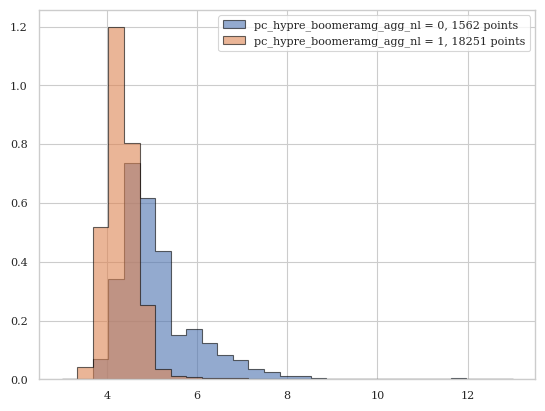

In [43]:
key = 'LinearTransformedScheme - hypre - pc_hypre_boomeramg_agg_nl'
make_hist(df_perf_detailed[df_perf_detailed[key] == 0], label='pc_hypre_boomeramg_agg_nl = 0')
make_hist(df_perf_detailed[df_perf_detailed[key] == 1], label='pc_hypre_boomeramg_agg_nl = 1')
plt.legend()

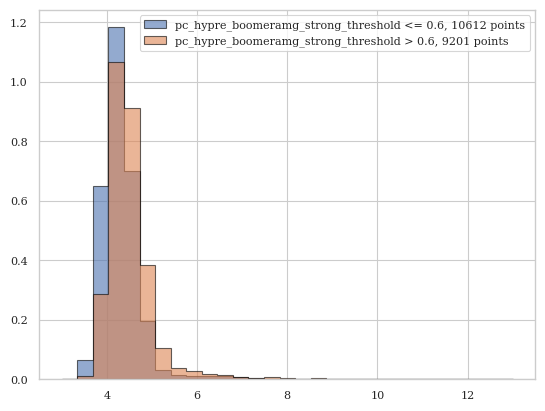

In [44]:
key = 'LinearTransformedScheme - hypre - pc_hypre_boomeramg_strong_threshold'
sep = 0.6
make_hist(df_perf_detailed[df_perf_detailed[key] <= sep], label=f'pc_hypre_boomeramg_strong_threshold <= {sep}')
make_hist(df_perf_detailed[df_perf_detailed[key] > sep], label=f'pc_hypre_boomeramg_strong_threshold > {sep}')
plt.legend()

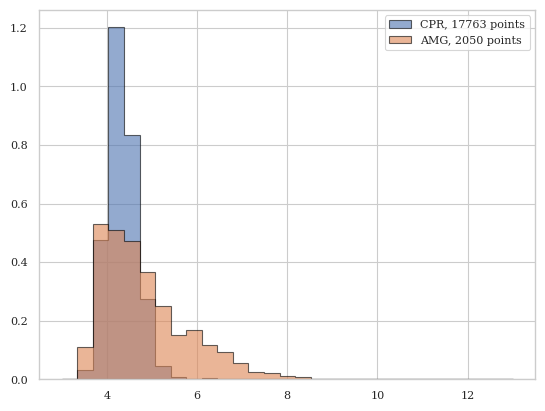

In [45]:
make_hist(df_perf_detailed[df_perf_detailed['PetscCompositeScheme'] == True], label='CPR')
make_hist(df_perf_detailed[df_perf_detailed['PetscFieldSplitScheme'] == True], label='AMG')
plt.legend()

In [46]:
list(df_perf_detailed.keys())

['seq_id',
 'sim_idx',
 'reward',
 'expectation',
 'decision_idx',
 'hypre - SOR/Jacobi',
 'hypre - V',
 'hypre',
 'PetscFieldSplitScheme - hypre - SOR/Jacobi',
 'PetscFieldSplitScheme - hypre - V',
 'PetscFieldSplitScheme - hypre',
 'PetscFieldSplitScheme',
 'PetscFieldSplitScheme - hypre - W',
 'PetscFieldSplitScheme - hypre - Jacobi',
 'PetscCompositeScheme - hypre - SOR/Jacobi',
 'PetscCompositeScheme - hypre - V',
 'PetscCompositeScheme - hypre',
 'PetscCompositeScheme - sor',
 'PetscCompositeScheme - ilu',
 'PetscCompositeScheme',
 'PetscCompositeScheme - none',
 'PetscCompositeScheme - hypre - W',
 'PetscCompositeScheme - hypre - Jacobi',
 'hypre - W',
 'hypre - Jacobi',
 'LinearTransformedScheme - hypre - pc_hypre_boomeramg_strong_threshold',
 'LinearTransformedScheme - hypre - pc_hypre_boomeramg_agg_nl',
 'LinearTransformedScheme - hypre - pc_hypre_boomeramg_grid_sweeps_all',
 'LinearTransformedScheme - PetscFieldSplitScheme - hypre - python_pc_hypre_boomeramg_strong_threshold

Way to write this:
* guide the reader's thoughts
* 


first present data from random
- show sorted curve
- say upfront that we expect AMG to be good and something else to be bad
- dig up some information that AMG fails
- solver selection has to deal with: kick out some bad amg setups
- context to the role of exploration
- 30% chance of hitting something really bad - don't want to do much exploration
- pick data from previous runs